# makes HBV for testing Aral Sea Balance


In [13]:
# General python
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr

# Niceties
from rich import print

# General eWaterCycle
import ewatercycle
import ewatercycle.forcing
import ewatercycle.models



In [14]:
from ewatercycle_DA import DA


## Load Data

In [15]:
# The name of the shapefile
shape_file_name = "Chatly_GRDC"  # river: Bedford Ouse at Roxton, England

# The time-window of the experiment
experiment_start_date = "1959-01-01T00:00:00Z"
experiment_end_date = "1961-12-31T00:00:00Z"

forcing_path_ERA5 = (
    Path.home()
    / "MSc_AralSea"
    / "book"
    / "thesis_projects"
    / "MSc"
    / "2025_Q1_AndreVanDerVeen_CEG"
    / "work_in_progress"
    / "Test_Aral"
    / "forcing_Chatly_GRDC_HBV_5961"
    / shape_file_name
    / "ERA5"
    / "own_shapefile"
)
# forcing_path_ERA5 = (
#     Path.cwd()
#     / "AralSea_Basin"
#     / "forcing_Kerki"
#     / shape_file_name
#     / "ERA5"
#     / "own_shapefile"
# )


# The path save directory of the ERA5 data
#forcing_path_ERA5 = Path.home() / "projects/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/Aral_Test/forcing" / shape_file_name / "ERA5" / "own_shapefile"
#forcing_path_ERA5.mkdir(exist_ok=True)
load_location = forcing_path_ERA5 / "work" / "diagnostic" / "script" 
ERA5_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=load_location)


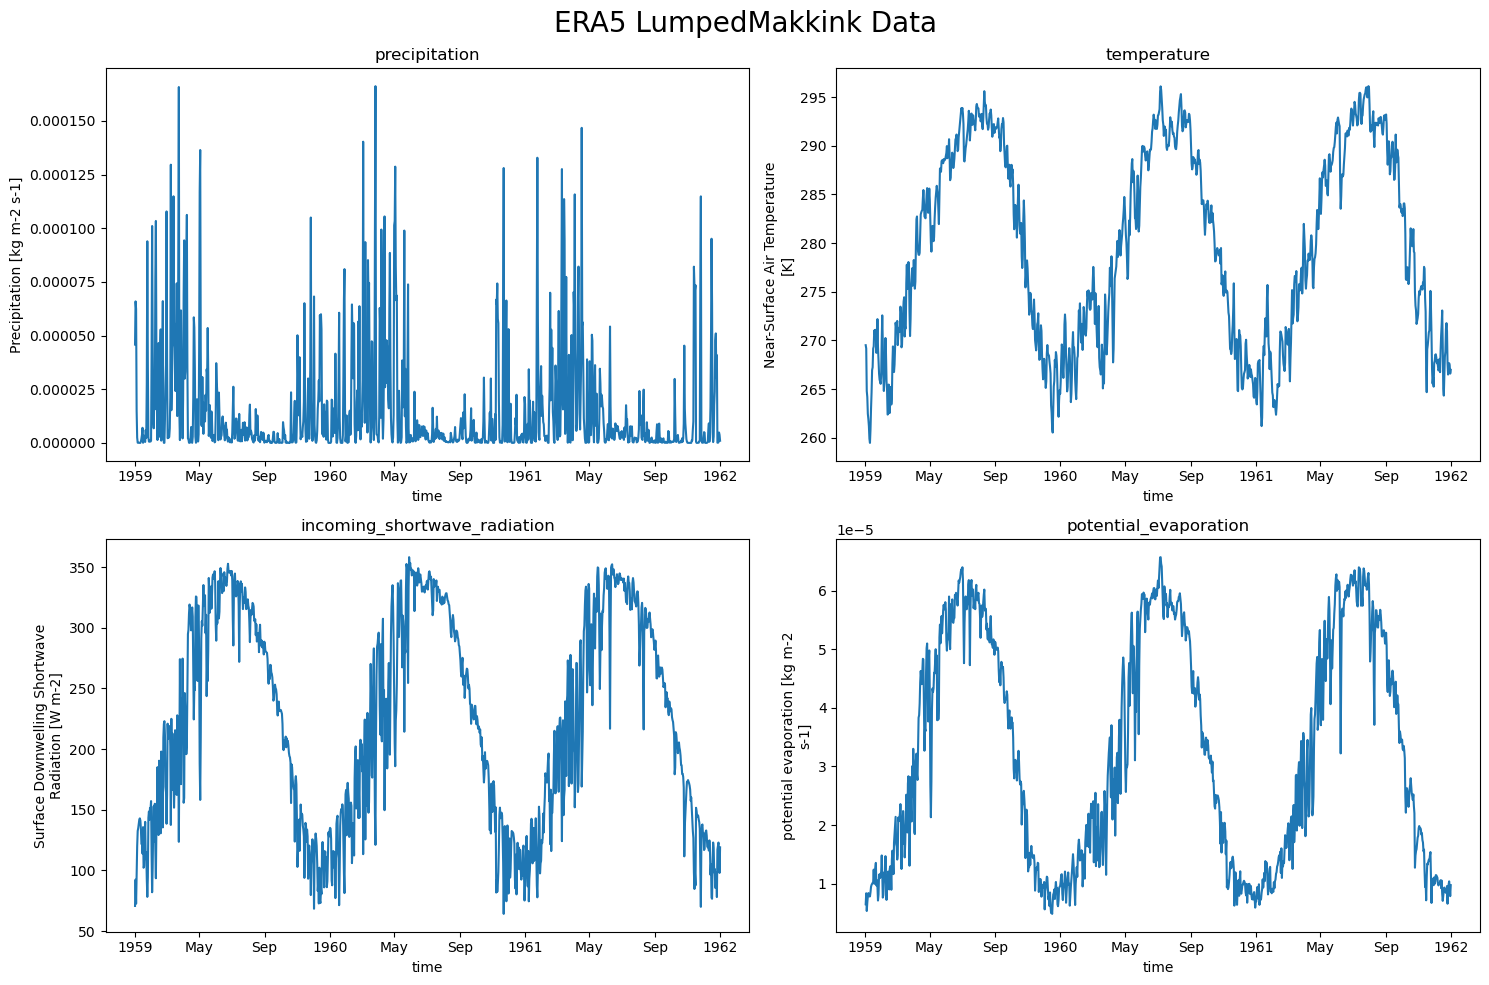

In [16]:
ERA5_data = {'precipitation pr': xr.open_dataset(ERA5_forcing['pr']),
             'temperature tas': xr.open_dataset(ERA5_forcing['tas']),
             'incoming_shortwave_radiation rsds': xr.open_dataset(ERA5_forcing['rsds']),
             'potential_evaporation evspsblpot': xr.open_dataset(ERA5_forcing['evspsblpot'])

             
}

plot_counter = 1
plt.figure(figsize=(15, 10))
for name, data in ERA5_data.items():
    plt.subplot(2,2, plot_counter)
    data[name.split(" ")[-1]].plot()
    plt.title(f"{name.split(" ")[0]}")
    plot_counter += 1

plt.suptitle("ERA5 LumpedMakkink Data", fontsize=20)
plt.tight_layout()

## HBV

In [17]:
n_particles = 250

In [18]:
## Array of initial storage terms - we keep these constant for now
##              Si,  Su, Sf, Ss
s_0 = np.array([0,  100,  0,  5, 0])

## Array of parameters min/max bounds as a reference
##                      Imax,  Ce,  Sumax, beta,  Pmax,  T_lag,   Kf,   Ks,    Fm
parameter_set_fromsomewhere =  [
    7.085,  # Imax
    0.837,  # Ce
    76.373, # Sumax
    1.112,  # Beta
    0.245,  # Pmax
    7.801,  # Tlag
    0.096,  # Kf
    0.003,  # Ks
    0.226   # FM
]


param_array = np.array(parameter_set_fromsomewhere)
# p_min_initial = np.array(parameter_set_fromsomewhere) * [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.1, 0.1, 0.5]
# p_max_initial = np.array(parameter_set_fromsomewhere) * [1.5, 2.5, 1.5, 1.5, 1.5, 5, 2, 2, 1.5]

#p_min_initial=  0.3 * param_array #np.array([0,   0.2,  40,    .5,   .001,   1,     .01,  .0001,   0.01])
#p_min_initial = np.array([0,   0.2,  40,    .5,   .001,   1,     .01,  .0001,   0.01])
p_min_initial = np.array([0,   0.2,  40,    .5,   .001,   1,     .01,  .0001,   0.01])
p_max_initial =np.array([25,    1,  800,   4,    .3,     120,    .04,   .01,      0.4])
#p_max_initial =np.array([25,    1,  800,   4,    .3,     80,    .1,   .01,      1])
#p_max_initial = 10 * param_array #np.array(10*parameter_set_fromsomewhere) # np.array([25,    1,  800,   4,    .3,     100,    .1,   .01,      1])
array_random_num = np.array([[np.random.random() for i in range(len(p_max_initial))] for i in range(n_particles)])
p_intial = p_min_initial + array_random_num * (p_max_initial-p_min_initial)




p_names = ["$I_{max}$",  "$C_e$",  "$Su_{max}$", "β",  "$P_{max}$",  "$T_{lag}$",   "$K_f$",   "$K_s$"]
S_names = ["Interception storage", "Unsaturated Rootzone Storage", "Fastflow storage", "Groundwater storage"]
param_names = ["Imax","Ce",  "Sumax", "Beta",  "Pmax",  "Tlag",   "Kf",   "Ks", "Fm"]
stor_names = ["Si", "Su", "Sf", "Ss", "Sp"]

# set initial as mean of max,min
#par_0 = (p_min_initial + p_max_initial)/2

In [19]:
array_random_num = np.array([[np.random.random() for i in range(len(p_max_initial))] for i in range(n_particles)])
p_intial = p_min_initial + array_random_num * (p_max_initial-p_min_initial)

In [20]:
array_random_num

array([[0.75842856, 0.7134529 , 0.42566459, ..., 0.83410846, 0.91629467,
        0.24819329],
       [0.56773439, 0.6106384 , 0.68019054, ..., 0.78447728, 0.51875243,
        0.0641956 ],
       [0.65163599, 0.17032052, 0.44530929, ..., 0.27591545, 0.71081606,
        0.3515675 ],
       ...,
       [0.4718679 , 0.15533123, 0.17462471, ..., 0.68057627, 0.06830045,
        0.24504362],
       [0.19695282, 0.04713763, 0.95165843, ..., 0.27690501, 0.21397185,
        0.68573268],
       [0.93232048, 0.74092215, 0.27831506, ..., 0.86571987, 0.40948268,
        0.57218084]])

In [21]:
p_intial[2]

array([1.62908998e+01, 3.36256417e-01, 3.78435063e+02, 1.66499088e+00,
       1.74333771e-01, 8.83524883e+01, 1.82774635e-02, 7.13707904e-03,
       1.47111323e-01])

In [22]:
ensemble = DA.Ensemble(N=n_particles)
ensemble.setup()




In [23]:
setup_kwargs_lst = []
for index in range(n_particles):
    setup_kwargs_lst.append({
        'parameters': list(p_intial[index]),  # list of floats
        'initial_storage': list(s_0),         # list of floats
    })

with open("setup_kwargs_lst_simple.txt", "w") as f:
    for i, kwargs in enumerate(setup_kwargs_lst):
        f.write(f"Particle {i}:\n")
        f.write(f"  parameters: {kwargs['parameters']}\n")
        f.write(f"  initial_storage: {kwargs['initial_storage']}\n\n")

In [24]:
ensemble.initialize(model_name=["HBV"]*n_particles,
                    forcing=[ERA5_forcing]*n_particles,
                    setup_kwargs=setup_kwargs_lst,
)


In [25]:
ref_model = ensemble.ensemble_list[0].model

In [26]:
from tqdm import tqdm

In [27]:
ref_model = ensemble.ensemble_list[0].model

n_timesteps = int((ref_model.end_time - ref_model.start_time) /  ref_model.time_step)

time = []
lst_Q = []
for i in tqdm(range(n_timesteps)):
    time.append(pd.Timestamp(ref_model.time_as_datetime.date()))
    ensemble.update()
    lst_Q.append(ensemble.get_value("Q").flatten())

ensemble.finalize()


100%|██████████| 1095/1095 [06:17<00:00,  2.90it/s]


In [28]:
Q_m_arr = np.array(lst_Q).T
df_ensemble = pd.DataFrame(data=Q_m_arr[:,:len(time)].T,index=time,columns=[f'particle {n}' for n in range(n_particles)])

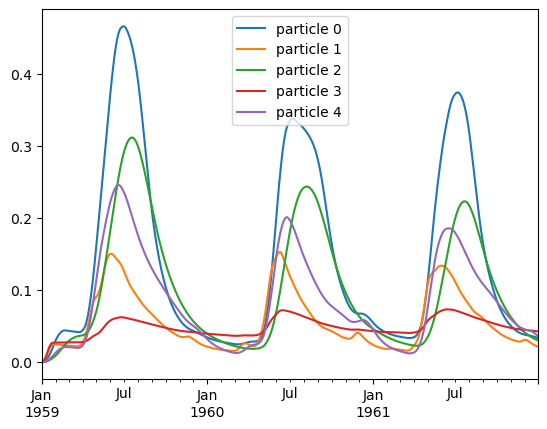

In [29]:
df_ensemble.iloc[:, :5].plot()
df_ensemble.to_csv("HBV_GRDC_Chatly_5961_ensemble.csv", index=True)

In [30]:


# ensemble = DA.Ensemble(N=10)
# ensemble.setup()

# ensemble.initialize(model_name="HBV",
#                    forcing=ERA5_forcing,
#                    setup_kwargs = {
#                         'parameters': [7.6,0.5,460,3.8,0.19,1.3,0.082,0.0061,0.26],
#                         'initial_storage': [0,100,0,5,0]
# })

# ref_model = ensemble.ensemble_list[0].model

# lst_Q = []
# while ref_model.time < ref_model.end_time:
#     ensemble.update(assimilate=False)
#     lst_Q.append(ensemble.get_value("Q"))

In [31]:
# ref_model = ensemble.ensemble_list[0].model

In [32]:
# n_timesteps = int((ref_model.end_time - ref_model.start_time) /  ref_model.time_step)

# time = []
# lst_Q = []
# for i in tqdm(range(n_timesteps)):
#     time.append(pd.Timestamp(ref_model.time_as_datetime.date()))
#     ensemble.update()
#     lst_Q.append(ensemble.get_value("flux_out_Q").flatten())

# ensemble.finalize()

In [33]:
# Q_m_arr = np.array(lst_Q).T
# df_ensemble = pd.DataFrame(data=Q_m_arr[:,:len(time)].T,index=time,columns=[f'particle {n}' for n in range(n_particles)])

In [34]:
# ax = df_ensemble[["particle 0"]].plot(lw=2.5)
# df_ensemble[["particle 1"]].plot(ax=ax,ls="--",lw=2.5)
# df_ensemble[["particle 2"]].plot(ax=ax,ls="-.",lw=1.5)

## rest code

In [35]:
parameter_set =  [
    15.085,  # Imax
    0.837,  # Ce
    76.373, # Sumax
    1.112,  # Beta
    0.245,  # Pmax
    7.801,  # Tlag
    0.096,  # Kf
    0.003,  # Ks
    0.226   # FM
]

initial_conditions = np.array([
    0,      # Si
    100,    # Su
    0,      # Sf
    5,      # Ss
    0       # Sp
])

In [36]:
#xr_model_output

In [37]:
#model_output

In [38]:

#model_output.to_csv("HBV_GRDC_Chatly_5000.csv", index=True)